In [1]:
from google.colab import files

print("Upload  .npy files:")
uploaded = files.upload()

Upload  .npy files:


Saving y_true_binary.npy to y_true_binary.npy
Saving X_test_sequences.npy to X_test_sequences.npy
Saving X_train_sequences.npy to X_train_sequences.npy


In [2]:
import numpy as np

X_train_sequences = np.load('X_train_sequences.npy')
X_test_sequences = np.load('X_test_sequences.npy')
y_true_binary = np.load('y_true_binary.npy')

print("=== Data Loaded Successfully ===")
print(f"X_train_sequences shape: {X_train_sequences.shape}")
print(f"X_test_sequences shape:  {X_test_sequences.shape}")
print(f"y_true_binary shape:     {y_true_binary.shape}")
print(f"\nLabel Distribution:")
print(f"  Normal (0):  {np.sum(y_true_binary == 0)}")
print(f"  Anomaly (1): {np.sum(y_true_binary == 1)}")

=== Data Loaded Successfully ===
X_train_sequences shape: (3588, 10, 128)
X_test_sequences shape:  (5122, 10, 128)
y_true_binary shape:     (5122,)

Label Distribution:
  Normal (0):  2496
  Anomaly (1): 2626


In [3]:
# Chronological 80/20 split (no shuffling - time series data)
split_idx = int(len(X_train_sequences) * 0.8)
X_train_fit = X_train_sequences[:split_idx]
X_val = X_train_sequences[split_idx:]

print("80/20 Chronological Split:")
print(f"  X_train_fit : {X_train_fit.shape}")
print(f"  X_val       : {X_val.shape}")

80/20 Chronological Split:
  X_train_fit : (2870, 10, 128)
  X_val       : (718, 10, 128)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, RepeatVector, TimeDistributed, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

seq_length = 10
feature_dim = 128

gru_autoencoder = Sequential([
    Input(shape=(seq_length, feature_dim), name="Temporal_Input"),

    # ENCODER
    GRU(64, activation='tanh', return_sequences=True, name="Encoder_GRU_1"),
    GRU(32, activation='tanh', return_sequences=False, name="Encoder_Bottleneck"),

    # BRIDGE
    RepeatVector(seq_length, name="Bridge_Repeater"),

    # DECODER
    GRU(32, activation='tanh', return_sequences=True, name="Decoder_GRU_1"),
    GRU(64, activation='tanh', return_sequences=True, name="Decoder_GRU_2"),

    TimeDistributed(Dense(feature_dim), name="Reconstruction_Output")
], name="GRU_Autoencoder")

gru_autoencoder.compile(optimizer='adam', loss='mse')
gru_autoencoder.summary()

# Training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining GRU Autoencoder...")
history = gru_autoencoder.fit(
    X_train_fit, X_train_fit,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)

Model: "GRU_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder_GRU_1 (GRU)             │ (None, 10, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Bottleneck (GRU)        │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bridge_Repeater (RepeatVector)  │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_GRU_1 (GRU)             │ (None, 10, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_GRU_2 (GRU)             │ (None, 10, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruction_Output           │ (None, 10, 128)        │         8,320 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,128 (313.00 KB)

 Trainable params: 80,128 (313.00 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU Autoencoder...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 4.8203e-04 - val_loss: 4.6333e-05
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.4659e-05 - val_loss: 2.4127e-05
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.9604e-06 - val_loss: 1.9224e-05
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.2190e-06 - val_loss: 1.7436e-05
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0035e-06 - val_loss: 1.6568e-05
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8506e-06 - val_loss: 1.5920e-05
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2139e-06 - val_loss: 1.5798e-05
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4309e-07 - val_loss: 1.5834e-05
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.1595e-07 - val_loss: 1.5458e-05
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7059e-07 - val_loss: 1.5527e-05
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# 1. Threshold calibration on validation set
val_reconstructions = gru_autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.square(X_val - val_reconstructions), axis=(1, 2))
mean_val_mse = np.mean(val_mse)
std_val_mse = np.std(val_mse)

print(f"Validation MSE  — Mean: {mean_val_mse:.8f} | Std: {std_val_mse:.8f}")

# 2. Score the full test set
test_reconstructions = gru_autoencoder.predict(X_test_sequences, verbose=0)
test_mse = np.mean(np.square(X_test_sequences - test_reconstructions), axis=(1, 2))
test_anomaly_scores = np.abs(test_mse - mean_val_mse)

# 3. Invert scores (same as LSTM notebook)
inverted_scores = -test_anomaly_scores

# 4. ROC AUC
roc_auc = roc_auc_score(y_true_binary, inverted_scores)
print(f"\nGRU Autoencoder ROC AUC: {roc_auc:.4f}")

# 5. Optimal threshold via Youden's J
fpr, tpr, thresholds = roc_curve(y_true_binary, inverted_scores)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

y_pred = (inverted_scores > optimal_threshold).astype(int)

print(f"Optimal Threshold: {optimal_threshold:.6e}")
print("\nClassification Report:")
print(classification_report(
    y_true_binary, y_pred,
    target_names=["Normal (0)", "Anomaly (1)"],
    zero_division=0
))

Validation MSE  — Mean: 0.00001528 | Std: 0.00000945

GRU Autoencoder ROC AUC: 0.9044
Optimal Threshold: -1.512276e-05

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.85      0.82      0.84      2496
 Anomaly (1)       0.84      0.86      0.85      2626

    accuracy                           0.84      5122
   macro avg       0.84      0.84      0.84      5122
weighted avg       0.84      0.84      0.84      5122



In [6]:
import pandas as pd

results = {
    "Model Variant": [
        "No CNN Pretraining + LSTM",
        "CNN Pretraining + LSTM",
        "CNN Pretraining + GRU"
    ],
    "ROC AUC": [0.4434, 0.8850, 0.9084],
    "Accuracy": [0.70, 0.84, 0.84],
    "Normal Precision": [0.24, 0.86, 0.86],
    "Normal Recall": [0.19, 0.81, 0.81],
    "Anomaly Precision": [0.79, 0.83, 0.83],
    "Anomaly Recall": [0.84, 0.87, 0.87],
    "Anomaly F1": [0.82, 0.85, 0.85],
    "Params": ["103,296", "103,296", "80,128"],
    "Stopped At Epoch": [25, 21, 29]
}

df = pd.DataFrame(results)
df = df.set_index("Model Variant")

print("=" * 90)
print("ABLATION STUDY RESULTS")
print("=" * 90)
print(df.to_string())
print("=" * 90)

ABLATION STUDY RESULTS
                           ROC AUC  Accuracy  Normal Precision  Normal Recall  Anomaly Precision  Anomaly Recall  Anomaly F1   Params  Stopped At Epoch
Model Variant                                                                                                                                          
No CNN Pretraining + LSTM   0.4434      0.70              0.24           0.19               0.79            0.84        0.82  103,296                25
CNN Pretraining + LSTM      0.8850      0.84              0.86           0.81               0.83            0.87        0.85  103,296                21
CNN Pretraining + GRU       0.9084      0.84              0.86           0.81               0.83            0.87        0.85   80,128                29


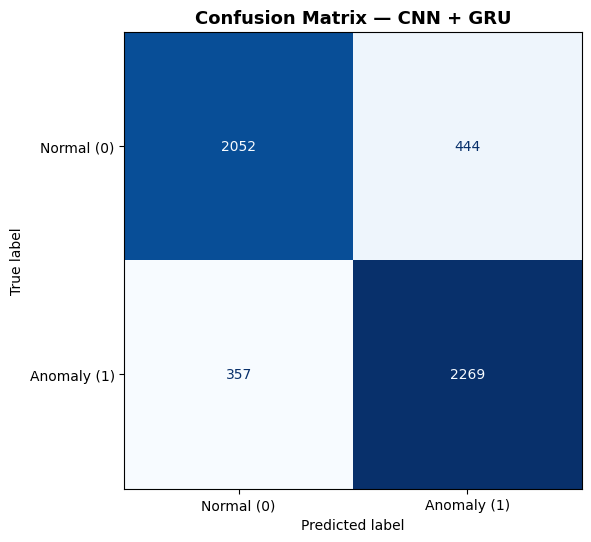

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_binary, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Anomaly (1)"]
)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

plt.title("Confusion Matrix — CNN + GRU", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_lstm_attention.png", dpi=150, bbox_inches='tight')
plt.show()